In [6]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score 

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer 

In [7]:
df = pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [9]:
df.dropna(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  714 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      714 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 22.3 KB


In [11]:
df.shape

(714, 3)

In [12]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [18]:
X = df.iloc[:,[1,2]]
y = df.iloc[:,0]
y

0      0
1      1
2      1
3      1
4      0
      ..
885    0
886    0
887    1
889    1
890    0
Name: Survived, Length: 714, dtype: int64

In [17]:
X

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
885,39.0,29.1250
886,27.0,13.0000
887,19.0,30.0000
889,26.0,30.0000


In [19]:
X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
X_train.head(4)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750


In [22]:
clf = DecisionTreeClassifier()

In [24]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [25]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [27]:
# cross val score 
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6330790297339594)

In [30]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [31]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [32]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [39]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [40]:
trf.named_transformers_['first']

,n_bins,15
,encode,'ordinal'
,strategy,'quantile'
,quantile_method,'warn'
,dtype,None
,subsample,200000
,random_state,None


In [ ]:
trf.named_transformers_['first'].n_bins_ # tells how many are created 

array([15])

In [48]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [49]:
trf.named_transformers_['second'].bin_edges_[0]

array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
        13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
        51.4792,  76.2917, 108.9   , 512.3292])

In [37]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1],
})

In [38]:
output

,age,age_trf,fare,fare_trf
328,31.0,8.0,20.5250,8.0
73,26.0,6.0,14.4542,7.0
253,30.0,8.0,16.1000,7.0
719,33.0,9.0,7.7750,2.0
666,25.0,6.0,13.0000,6.0
...,...,...,...,...
92,46.0,12.0,61.1750,12.0
134,25.0,6.0,13.0000,6.0
337,41.0,11.0,134.5000,14.0
548,33.0,9.0,20.5250,8.0


In [50]:
output['age_labels']  = pd.cut(x=X_train['Age'],
                               bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                               bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [55]:
trf.named_transformers_['first'].bin_edges_[0].tolist()

[0.42,
 6.0,
 16.0,
 19.0,
 21.0,
 23.0,
 25.0,
 28.0,
 30.0,
 32.0,
 35.0,
 38.0,
 42.0,
 47.0,
 54.0,
 80.0]

In [54]:
trf.named_transformers_['second'].bin_edges_[0].tolist()

[0.0,
 7.25,
 7.775,
 7.8958,
 8.1583,
 10.5,
 13.0,
 14.4542,
 18.75,
 26.0,
 26.55,
 31.275,
 51.4792,
 76.2917,
 108.90000000000023,
 512.3292]

In [53]:
output.sample(10)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
592,47.0,13.0,7.2500,1.0,"(42.0, 47.0]","(0.0, 7.25]"
683,14.0,1.0,46.9000,11.0,"(6.0, 16.0]","(31.275, 51.479]"
237,8.0,1.0,26.2500,9.0,"(6.0, 16.0]","(26.0, 26.55]"
879,56.0,14.0,83.1583,13.0,"(54.0, 80.0]","(76.292, 108.9]"
38,18.0,2.0,18.0000,7.0,"(16.0, 19.0]","(14.454, 18.75]"
515,47.0,13.0,34.0208,11.0,"(42.0, 47.0]","(31.275, 51.479]"
654,18.0,2.0,6.7500,0.0,"(16.0, 19.0]","(0.0, 7.25]"
27,19.0,3.0,263.0000,14.0,"(16.0, 19.0]","(108.9, 512.329]"
705,39.0,11.0,26.0000,9.0,"(38.0, 42.0]","(18.75, 26.0]"
806,39.0,11.0,0.0000,0.0,"(38.0, 42.0]",NaN


In [60]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2  = clf.predict(X_test_trf)

In [61]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [63]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6723004694835681)

In [72]:
def discretize(bins,strategy):
    kbinage = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbinfare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbinage,[0]),
        ('second',kbinfare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='Red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='Red')
    plt.title("After")
    plt.show()


In [ ]:
X_trf # this is numpy array so we can't use X_trf['Fare] so intead of this we need to write X_trf[:,1]

array([[ 4.,  1.],
       [11., 13.],
       [ 6.,  3.],
       ...,
       [ 3., 10.],
       [ 6., 10.],
       [ 9.,  1.]], shape=(714, 2))

0.6723004694835681


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


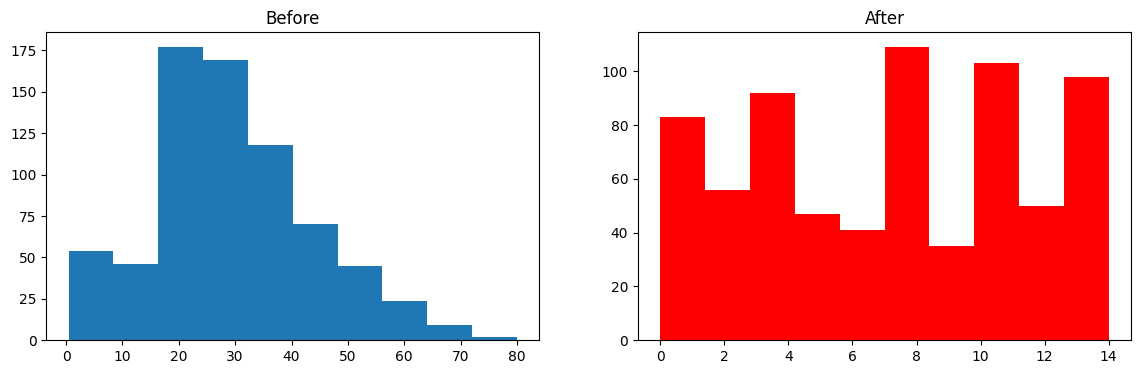

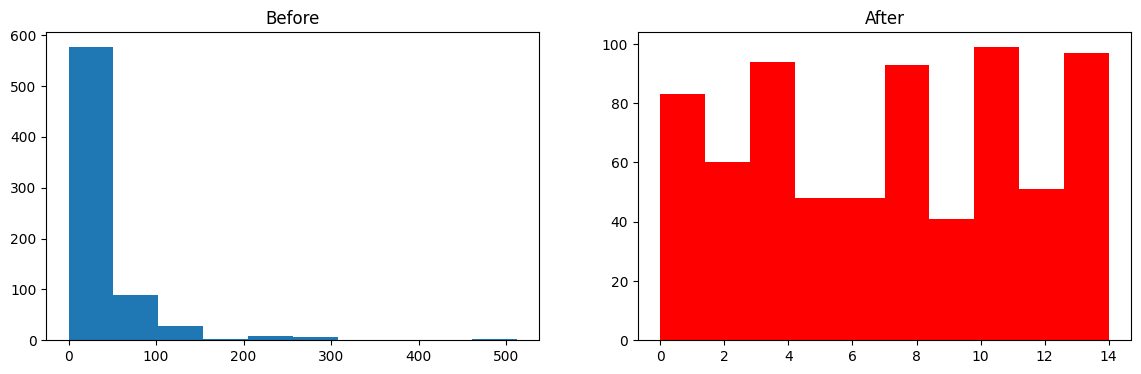

In [73]:
discretize(15,'quantile')